# 8 · Splitting an advertising budget

A shop has a quarter's advertising budget to split over TV, search and social ads. You will see
why common rules of thumb leave sales on the table, how `allocate` finds the best split and
certifies how close it is to the best, and why TV, which only pays above a threshold, is easy to
miss. Both modules used here, `chc.response` and `chc.allocation`, are experimental: they may
change in any release.

In [1]:
import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_platforms", "cpu")  # the outputs below were made on a CPU
%matplotlib inline

from chc.allocation import allocate
from chc.response import (
    Channel,
    GeometricAdstock,
    Hill,
    MichaelisMenten,
    contribution,
    marginal_roi,
    roi,
    steady_state_marginal_roi,
)

COLOURS = {"TV": "#4C78A8", "search": "#F58518", "social": "#B279A2"}
MARKERS = {"TV": "o", "search": "s", "social": "^"}
GREEN, RED = "#54A24B", "#E45756"  # the best split, and the rules of thumb

## 1 · Three channels

All money is in thousands of euros (k€), spend and sales alike. Each channel gets one weekly
spend for the whole quarter. Two everyday effects shape what that spend sells.

- **Carryover.** An ad keeps selling after the week it runs, because people remember it. A
  channel's *adstock* in a week is that week's spend plus what is left of the spend of earlier
  weeks. `GeometricAdstock(retention, length=…, normalized=True)` passes the share `retention`
  of a euro's effect on from one week to the next, for `length` weeks in all. `normalized=True`
  makes the weights add up to one, so a euro's effect is spread over the weeks, not multiplied.
- **Saturation.** Each extra euro buys less: the fifth ad a person sees adds less than the
  first. A curve `h` turns the adstock into a share of the channel's ceiling: it rises from zero
  and flattens out at 1. A week's extra sales are `coefficient · h(adstock)`, where the
  coefficient is the ceiling, the most the channel can sell in a week. `MichaelisMenten(scale)`
  rises fastest at zero. `Hill(scale, slope)` with a slope above 1 is S-shaped: flat at first,
  then steep, then flat again. Both reach half the ceiling when the adstock equals `scale`.

Search saturates early and social later. TV is S-shaped, and its carryover is the longest.

In [2]:
WEEKS = 13  # one quarter
BUDGET = 780.0  # k€ for the quarter
channels = {
    "TV": Channel(
        kernel=GeometricAdstock(retention=0.6, length=8, normalized=True),
        curve=Hill(scale=25.0, slope=3.0),
        coefficient=90.0,
    ),
    "search": Channel(
        kernel=GeometricAdstock(retention=0.2, length=3, normalized=True),
        curve=MichaelisMenten(scale=8.0),
        coefficient=45.0,
    ),
    "social": Channel(
        kernel=GeometricAdstock(retention=0.4, length=5, normalized=True),
        curve=MichaelisMenten(scale=35.0),
        coefficient=100.0,
    ),
}
names = list(channels)
# the quarter, and the weeks after it while the longest carryover runs out
COUNTED = WEEKS + max(channel.kernel.length for channel in channels.values()) - 1


def weekly(rate: float) -> np.ndarray:
    """`rate` k€ every week of the quarter, then nothing while the carryover runs out."""
    return np.concatenate([np.full(WEEKS, rate), np.zeros(COUNTED - WEEKS)])


def extra_sales(split) -> float:
    """The quarter's extra sales, carryover included, from a weekly spend on each channel."""
    pairs = zip(channels.values(), split, strict=True)
    return sum(contribution(channel, weekly(rate)) for channel, rate in pairs)


print(f"The quarter: {WEEKS} weeks and {BUDGET:.0f} k€, {BUDGET / WEEKS:.0f} k€ a week.")
print(f"Sales are counted over {COUNTED} weeks, until the longest carryover runs out.")
weights = {name: pd.Series(channel.kernel.weights()) for name, channel in channels.items()}
carryover = pd.DataFrame(weights).fillna(0.0).rename_axis("weeks after the spend")
carryover.round(2)

The quarter: 13 weeks and 780 k€, 60 k€ a week.
Sales are counted over 20 weeks, until the longest carryover runs out.


,TV,search,social
weeks after the spend,,,
0,0.41,0.81,0.61
1,0.24,0.16,0.24
2,0.15,0.03,0.10
3,0.09,0.00,0.04
4,0.05,0.00,0.02
5,0.03,0.00,0.00
6,0.02,0.00,0.00
7,0.01,0.00,0.00


Each column shows how a euro's effect is spread over the weeks after it is spent. TV's effect
lasts the longest, and only 0.41 of it lands in the week of the spend; search's lands mostly in
that week, 0.81. Sales are counted over 20 weeks in all, until the carryover has run out, so
that TV is not undervalued for the sales that land after the quarter.

The plot on the left draws the table. The plot on the right shows what a quarter of steady
weekly spend sells on each channel.

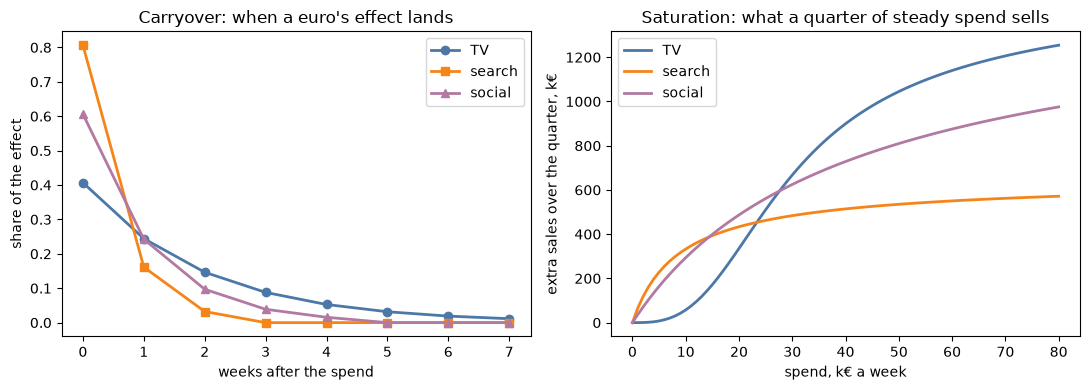

,TV,search,social
k€ a week,,,
5.0,8.0,228.0,164.0
10.0,57.0,333.0,294.0
20.0,335.0,434.0,487.0
40.0,899.0,514.0,728.0
80.0,1254.0,571.0,975.0


In [3]:
levels = np.linspace(0.0, 80.0, 81)
quarter = pd.DataFrame(
    {name: [contribution(ch, weekly(level)) for level in levels] for name, ch in channels.items()},
    index=pd.Index(levels, name="k€ a week"),
)

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))
for name in names:
    colour = COLOURS[name]
    left.plot(
        carryover.index, carryover[name], marker=MARKERS[name], lw=2, color=colour, label=name
    )
    right.plot(levels, quarter[name], lw=2, color=colour, label=name)
left.set_xlabel("weeks after the spend")
left.set_ylabel("share of the effect")
left.set_title("Carryover: when a euro's effect lands")
left.legend()
right.set_xlabel("spend, k€ a week")
right.set_ylabel("extra sales over the quarter, k€")
right.set_title("Saturation: what a quarter of steady spend sells")
right.legend()
plt.tight_layout()
plt.show()

quarter.loc[[5.0, 10.0, 20.0, 40.0, 80.0]].round(0)

From 5 to 80 k€ a week, search's sales over the quarter only grow from 228 to 571 k€: it
saturates early. TV sells almost nothing at first, 8 k€ for 5 k€ a week, then climbs steeply, to
899 k€ at 40 k€ a week. Social is in between.

## 2 · Three rules of thumb

Last quarter the shop split a smaller budget its own way, and its report showed what each
channel returned. The *average return per euro* (what a report calls ROI or ROAS) is a channel's
extra sales divided by its spend; `roi` reads it, carryover included.

In [4]:
QUARTER = slice(0, WEEKS)  # the weeks whose spend a reading is about
last_quarter = np.array([10.0, 15.0, 20.0])  # k€ a week on TV, search and social
pairs = list(zip(channels.values(), last_quarter, strict=True))
report = pd.DataFrame(
    {
        "k€ a week": last_quarter,
        "extra sales, k€": [contribution(c, weekly(r)) for c, r in pairs],
        "average per euro": [roi(c, weekly(r), QUARTER) for c, r in pairs],
    },
    index=names,
)
report.round(2)

,k€ a week,"extra sales, k€",average per euro
TV,10.0,57.29,0.44
search,15.0,393.47,2.02
social,20.0,486.96,1.87


Last quarter the shop spent 10 k€ a week on TV, 15 on search and 20 on social. Search returned
the most per euro, 2.02 €, and TV the least, 0.44 €: at 10 k€ a week TV is still on the flat
start of its curve.

This quarter the budget is 780 k€, 60 k€ a week. Three common ways to split it:

1. the same amount on every channel;
2. the same shares as last quarter;
3. everything on the channel with the best average return per euro last quarter.

Each split is scored the way `allocate` scores a plan: the extra sales its spend brings over
spending nothing, in the quarter and in the weeks after while the carryover runs out.

In [5]:
per_week = BUDGET / WEEKS
top = report["average per euro"].idxmax()
rules = {
    "equal split": np.full(3, per_week / 3),
    "same shares as last quarter": last_quarter / last_quarter.sum() * per_week,
    f"all on {top}": np.where(np.array(names) == top, per_week, 0.0),
}
scores = pd.DataFrame.from_dict(
    {rule: [*split, extra_sales(split)] for rule, split in rules.items()},
    orient="index",
    columns=[*names, "extra sales, k€"],
)
scores["per euro"] = scores["extra sales, k€"] / BUDGET
scores.round(2)

,TV,search,social,"extra sales, k€",per euro
equal split,20.00,20.0,20.00,1255.85,1.61
same shares as last quarter,13.33,20.0,26.67,1143.46,1.47
all on search,0.00,60.0,0.00,550.34,0.71


The first three columns are the weekly spend in k€. Everything on search is the worst rule by
far: search saturates, and 780 k€ sells only 550 k€, 0.71 € per euro. The equal split does best
of the three, with 1256 k€.

## 3 · The best split

`allocate(channels, budget, periods, lower=…, upper=…)` finds the weekly spend on each channel
that sells the most. `lower` and `upper` are the box: the least and the most each channel may
spend in a week. A box should stay where the curves were measured, since outside it they are
guesses.

In [6]:
LOWER, UPPER = np.zeros(3), np.full(3, 100.0)


def plan(budget: float):
    return allocate(list(channels.values()), budget, WEEKS, lower=LOWER, upper=UPPER)


best = plan(BUDGET)
print(f"best.gain {best.gain:.4f} k€; extra_sales(best.spend) {extra_sales(best.spend):.4f} k€")
pd.DataFrame({"lower": LOWER, "upper": UPPER, "best, k€ a week": best.spend}, index=names).round(2)

best.gain 1539.4166 k€; extra_sales(best.spend) 1539.4166 k€


,lower,upper,"best, k€ a week"
TV,0.0,100.0,38.19
search,0.0,100.0,7.73
social,0.0,100.0,14.08


Each channel may spend from 0 to 100 k€ a week. `best.gain` is the plan's extra sales over
spending nothing, and `extra_sales`, which scored the rules of thumb, gives the same 1539.4166
k€ for the plan.

allocate sells 23% more than the equal split


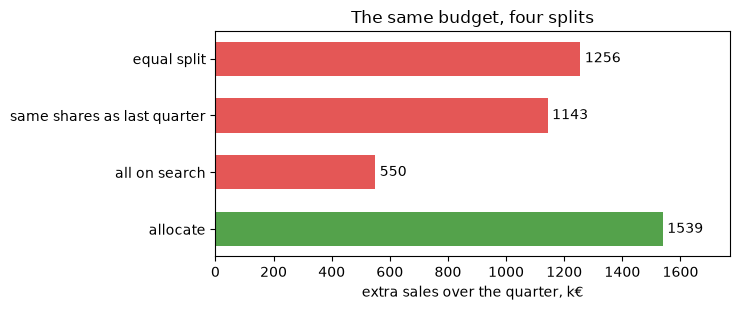

,TV,search,social,"extra sales, k€",per euro
equal split,20.00,20.00,20.00,1255.85,1.61
same shares as last quarter,13.33,20.00,26.67,1143.46,1.47
all on search,0.00,60.00,0.00,550.34,0.71
allocate,38.19,7.73,14.08,1539.42,1.97


In [7]:
scores.loc["allocate"] = [*best.spend, best.gain, best.gain / BUDGET]
uplift = best.gain / scores["extra sales, k€"] - 1.0
print(f"allocate sells {uplift['equal split']:.0%} more than the equal split")

fig, ax = plt.subplots(figsize=(7.5, 3.2))
colours = [GREEN if rule == "allocate" else RED for rule in scores.index]
ax.barh(scores.index, scores["extra sales, k€"], color=colours, height=0.6)
for row, value in enumerate(scores["extra sales, k€"]):
    ax.text(value + 15, row, f"{value:.0f}", va="center")
ax.invert_yaxis()
ax.set_xlim(0, 1.15 * scores["extra sales, k€"].max())
ax.set_xlabel("extra sales over the quarter, k€")
ax.set_title("The same budget, four splits")
plt.tight_layout()
plt.show()

scores.round(2)

The best split puts 38.2 k€ a week on TV, 7.7 on search and 14.1 on social. It sells 1539 k€,
1.97 € per euro: 23 % more than the equal split. TV gets the most money, although last quarter
it returned the least per euro. (`allocate` can also take last quarter's spend as `history`, so
that its carryover into this quarter is counted.)

TV's S-curve makes this a hard search: a split can look best against every small change and
still not be the best. So `allocate` reports a certificate along with the plan.

- `best.worth`: what the plan sells; with nothing spent before the quarter, it is `best.gain`.
- `best.bound`: no split inside the box sells more than this.
- `best.bound - best.worth`: so the plan is at most this far from the best split there is.
- `best.stopped`: `"closed"` when that gap has shrunk to almost nothing; `"cap"` when the search
  ran out of boxes first, and the gap is reported as it stands.

In [8]:
print(f"worth {best.worth:.4f} k€, bound {best.bound:.4f} k€")
print(f"the plan is at most {1000 * (best.bound - best.worth):.6f} € short of the best split")
print(f"stopped: {best.stopped!r}, after searching {best.boxes} boxes")

worth 1539.4166 k€, bound 1539.4166 k€
the plan is at most 0.000052 € short of the best split
stopped: 'closed', after searching 11 boxes


The search closed: no split of 780 k€ inside the box sells even a cent more than this plan.

## 4 · Why it is the best

The *return on the next euro* (the marginal return) is what one more euro on a channel would
sell, spread evenly over the quarter; `marginal_roi` reads it. At the best split, every channel
that is not at a limit of its box returns the same on its next euro. If one returned more,
moving a euro to it from another channel would sell more, and the split would not be the best.
That common value is `best.price`: what one more euro of budget would sell.

The table compares the two returns at the equal split and at the best split.

In [9]:
def returns(split) -> pd.DataFrame:
    """Each channel's weekly spend, average return per euro, and return on the next euro."""
    pairs = list(zip(channels.values(), split, strict=True))
    return pd.DataFrame(
        {
            "k€ a week": split,
            "average per euro": [roi(c, weekly(r), QUARTER) for c, r in pairs],
            "next euro": [marginal_roi(c, weekly(r), QUARTER) for c, r in pairs],
        },
        index=names,
    )


print(f"best.price = {best.price:.2f}: one more euro of budget sells {best.price:.2f} € more")
equal_and_best = {"equal split": returns(rules["equal split"]), "best split": returns(best.spend)}
pd.concat(equal_and_best, axis=1).round(2)

best.price = 1.52: one more euro of budget sells 1.52 € more


equal split                            best split                   \
         k€ a week average per euro next euro  k€ a week average per euro   
TV            20.0             1.29      2.70      38.19             1.74   
search        20.0             1.67      0.51       7.73             2.92   
social        20.0             1.87      1.24      14.08             2.08   

                  
       next euro  
TV          1.52  
search      1.52  
social      1.52

At the equal split, social has the best average return, 1.87 € per euro. Yet TV's next euro
returns the most, 2.70 €, and search's the least, 0.51 €. So money should move from search to
TV, which the averages never suggest. At the best split, the next euro returns 1.52 € on every
channel: that is `best.price`. Search now has by far the best average, 2.92 €, yet it gets the
least money. An average mixes the first, cheap euros with the last ones; only the next euro says
where more money should go.

The plot shows each channel's return on the next euro at every weekly spend. The best split is
where the three curves cross one height, the price. A channel held at its upper limit would
return more there, and one held at its lower limit less.

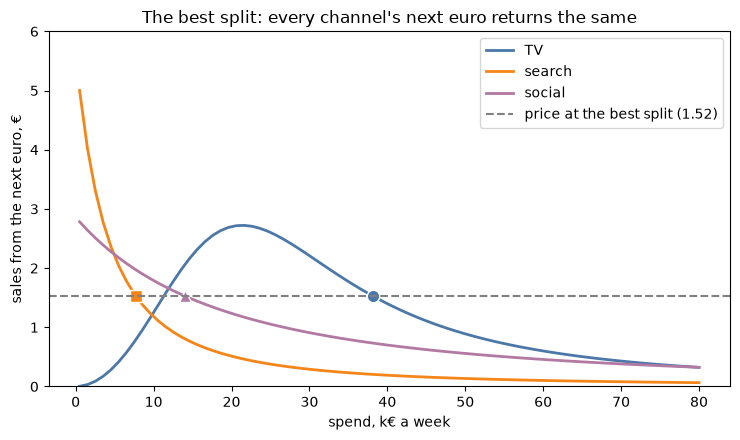

In [10]:
grid = np.linspace(0.5, 80.0, 80)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for name, channel in channels.items():
    next_euro = [marginal_roi(channel, weekly(level), QUARTER) for level in grid]
    ax.plot(grid, next_euro, lw=2, color=COLOURS[name], label=name)
for name, rate in zip(names, best.spend, strict=True):
    ax.plot(rate, best.price, MARKERS[name], ms=9, color=COLOURS[name], markeredgecolor="white")
ax.axhline(best.price, ls="--", c="0.5", label=f"price at the best split ({best.price:.2f})")
ax.set_xlabel("spend, k€ a week")
ax.set_ylabel("sales from the next euro, €")
ax.set_title("The best split: every channel's next euro returns the same")
ax.set_ylim(0, 6)
ax.legend()
plt.tight_layout()
plt.show()

TV's curve rises before it falls, and it crosses the price twice. The first crossing, at a low
spend, is not a best split: there each extra euro on TV returns more than the one before, so
moving more money to TV keeps paying until its curve falls back to the price.

## 5 · The threshold

How does the best split change with the budget? `allocate` plans the quarter again for budgets
below and above this one.

In [11]:
budgets = WEEKS * np.array([10.0, 20.0, 30.0, 34.0, 35.0, 60.0, 80.0, 100.0])
# this quarter's budget is planned above already
plans = [best if budget == BUDGET else plan(budget) for budget in budgets]
sweep = pd.DataFrame(
    [p.spend for p in plans], columns=names, index=pd.Index(budgets, name="budget, k€")
)
sweep["extra sales, k€"] = [p.gain for p in plans]
sweep["price"] = [p.price for p in plans]
print("every search closed:", all(p.stopped == "closed" for p in plans))
sweep.round(2)

every search closed: True


,TV,search,social,"extra sales, k€",price
"budget, k€",,,,,
130.0,0.00,4.93,5.07,392.13,2.22
260.0,0.00,7.31,12.69,637.66,1.61
390.0,0.00,9.67,20.33,819.82,1.22
442.0,0.00,10.61,23.39,880.30,1.11
455.0,27.45,4.35,3.20,908.65,2.43
780.0,38.19,7.73,14.08,1539.42,1.52
1040.0,45.36,10.76,23.88,1874.93,1.09
1300.0,52.09,13.88,34.03,2120.00,0.81


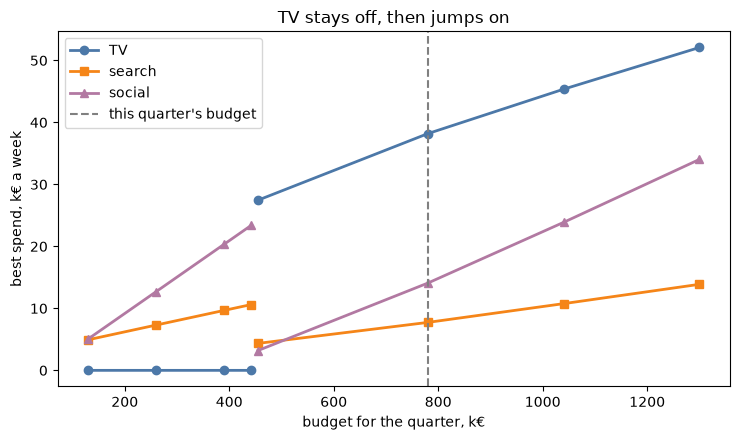

In [12]:
# no line across the jump, where TV switches on
switch = int(np.argmax(sweep["TV"].to_numpy() > 0))
x = np.insert(budgets, switch, np.nan)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for name in names:
    y = np.insert(sweep[name].to_numpy(), switch, np.nan)
    ax.plot(x, y, marker=MARKERS[name], lw=2, color=COLOURS[name], label=name)
ax.axvline(BUDGET, ls="--", c="0.5", label="this quarter's budget")
ax.set_xlabel("budget for the quarter, k€")
ax.set_ylabel("best spend, k€ a week")
ax.set_title("TV stays off, then jumps on")
ax.legend()
plt.tight_layout()
plt.show()

Up to 442 k€ the best split leaves TV off and shares the budget between search and social. At
455 k€ it puts 27.45 k€ a week on TV at once, and takes money from search and social to do it.
Small amounts on TV are wasted, because its S-curve is flat at low spend: below the threshold,
what TV could get sells more on the other channels.

A planner that only follows the slope never makes that jump. Call it a climber: it starts from
zero spend and puts each next step of spend on the channel where that step sells the most right
now. At zero spend, TV's next euro sells nothing. `steady_state_marginal_roi` reads what one more
euro a week sells once a steady spend has built up its adstock; here it is read at zero spend.

In [13]:
print({name: round(steady_state_marginal_roi(ch, 0.0), 2) for name, ch in channels.items()})


def climb(per_week: float, step: float = 1.0) -> np.ndarray:
    """Spend `per_week` a step at a time, each step on the channel where it sells the most now."""
    split = np.zeros(3)
    for _ in range(round(per_week / step)):
        pairs = zip(channels.values(), split, strict=True)
        gains = [contribution(c, weekly(r + step)) - contribution(c, weekly(r)) for c, r in pairs]
        split[np.argmax(gains)] += step
    return split


climbed = climb(per_week)
print("the climber's split, k€ a week:", dict(zip(names, climbed.round(1).tolist(), strict=True)))
sold = extra_sales(climbed)
print(f"it sells {sold:.0f} k€, {best.gain - sold:.0f} k€ less than allocate's split")

{'TV': 0.0, 'search': 5.62, 'social': 2.86}


the climber's split, k€ a week: {'TV': 0.0, 'search': 17.0, 'social': 43.0}
it sells 1166 k€, 373 k€ less than allocate's split


TV's next euro at zero spend sells 0 €, against 5.62 € on search and 2.86 € on social. So the
climber never takes the first step onto TV. It stops with nothing on TV, 17 k€ a week on search
and 43 on social. From there, any small move of money onto TV sells less, so a planner that
follows the slope sees no reason to try one. It sells 1166 k€: 373 k€ less than `allocate`'s
split, and less than even the equal split.

`allocate` does not follow the slope. It cuts each channel's range of spend into boxes, and in
each box it lays a straight roof over the S-curve: no split in the box can sell more than the
roof allows. It keeps cutting the box with the highest roof until no roof left stands above the
best split it has found. That is how it finds the threshold, and how it certifies the plan.

## 6 · What the next euro returns as the budget grows

As the budget grows, every channel moves further up its saturation curve, so the price, what one
more euro of budget sells, mostly falls. Where it falls below 1, the next euro of advertising
sells less than a euro.

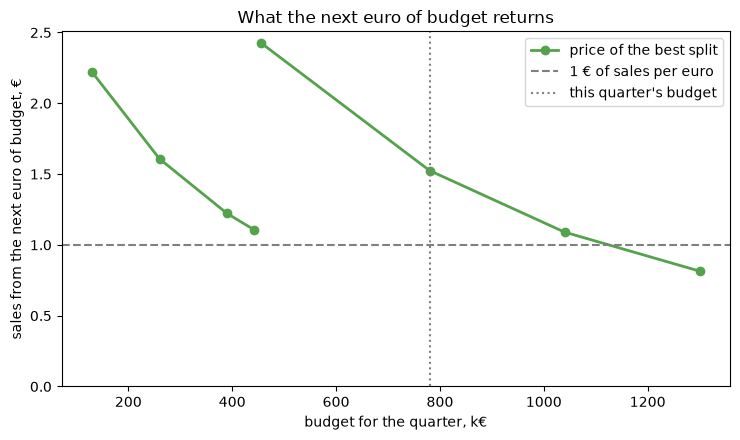

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
price = np.insert(sweep["price"].to_numpy(), switch, np.nan)
ax.plot(x, price, marker="o", lw=2, color=GREEN, label="price of the best split")
ax.axhline(1.0, ls="--", c="0.5", label="1 € of sales per euro")
ax.axvline(BUDGET, ls=":", c="0.5", label="this quarter's budget")
ax.set_xlabel("budget for the quarter, k€")
ax.set_ylabel("sales from the next euro of budget, €")
ax.set_title("What the next euro of budget returns")
ax.set_ylim(0, None)
ax.legend()
plt.tight_layout()
plt.show()

The price falls from 2.22 at 130 k€ to 1.11 at 442 k€. It jumps to 2.43 at 455 k€, where TV
switches on: search and social give up money, so their next euro returns more again. Then it
falls once more: 1.52 at this quarter's 780 k€, 1.09 at 1040 k€ and 0.81 at 1300 k€. So
somewhere between 1040 and 1300 k€ the next euro of advertising stops selling its own value.
Whether a euro of sales pays for a euro of advertising depends on the margin on those sales: a
price above 1 is not yet a profit.

## Takeaways

- Score a split by the extra sales of the whole quarter, carryover included, as `allocate`
  does. Average returns per euro do not say where the next euro should go.
- At the best split, the next euro returns the same on every channel not at a limit:
  `Allocation.price`.
- An S-shaped channel such as TV is off below a threshold budget and jumps on above it. A
  planner that follows the slope from zero spend never switches it on.
- `allocate` searches for the best split anyway, and `bound - worth` with `stopped` certifies
  how close its plan is to the best inside the box.